<a href="https://colab.research.google.com/github/NadiiaDataAnalyst/Data-Driven-Process-Optimization-Project-2024-2025-/blob/main/Project_work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [97]:
import pandas as pd
from google.colab import files


# LOADING

In [98]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [99]:
path = '/content/drive/MyDrive/РЕЕСТР ОФОРМЛЕННЫХ  ДЕКЛАРАЦИЙ 2024.xlsx'

In [100]:
df = pd.read_excel(path, sheet_name=None)
dfs = pd.concat(df.values(), ignore_index=True)
dfs

,№,Дата,Тип Деклараций,Номер Деклараций,Заказчик,Товар,Брокер,Номер Деклараций
0,1.0,2024-01-02 00:00:00,ЕК11АА,000021U1,ДСР,судно,Ирина,NaN
1,2.0,2024-01-02 00:00:00,ЕК10РР,017517U3,Долинський Елеватор,пшеница,Лиана,NaN
2,3.0,2024-01-03 00:00:00,ЕК10ДР,000048U4,Золотой Дракон,шрот,Надя,NaN
3,4.0,2024-01-03 00:00:00,ЕК10ДР,000054U2,Белогви,кукуруза,Надя,NaN
4,5.0,2024-01-03 00:00:00,ЕК10РР,017579U9,Китайпром,пшеница,Надя,NaN
...,...,...,...,...,...,...,...,...
736,9.0,2025-12-23 00:00:00,IM51ДЕ,NaN,Дунайсудоремонт,судно,Лиана,25UA500530004118U4
737,10.0,2025-12-25 00:00:00,IM40AA,NaN,Дунайсудоремонт,брухт,Надя,25UA500530004153U7
738,11.0,2025-12-26 00:00:00,ЕК10ДР,NaN,"ПП ""ГІДРОСЕНД""",шрот п.,Надя,25UA500530004160U4
739,12.0,2025-12-29 00:00:00,ЕК10РР,NaN,Промбудресурс КР,шлак,Надя,25UA500530004188U6


In [101]:
print(dfs.columns.tolist())

['№ ', 'Дата', 'Тип Деклараций', 'Номер Деклараций ', 'Заказчик', 'Товар', 'Брокер', 'Номер Деклараций']


In [102]:
pd.options.mode.chained_assignment = None

# CLEANUP

In [103]:
dfs['ID of declaration'] = dfs['Номер Деклараций '].fillna(dfs['Номер Деклараций'])


In [104]:
columns_to_drop = ['Номер Деклараций ', 'Номер Деклараций', '№ ']

In [105]:
dfs.drop(columns=columns_to_drop, inplace=True)
dfs

,Дата,Тип Деклараций,Заказчик,Товар,Брокер,ID of declaration
0,2024-01-02 00:00:00,ЕК11АА,ДСР,судно,Ирина,000021U1
1,2024-01-02 00:00:00,ЕК10РР,Долинський Елеватор,пшеница,Лиана,017517U3
2,2024-01-03 00:00:00,ЕК10ДР,Золотой Дракон,шрот,Надя,000048U4
3,2024-01-03 00:00:00,ЕК10ДР,Белогви,кукуруза,Надя,000054U2
4,2024-01-03 00:00:00,ЕК10РР,Китайпром,пшеница,Надя,017579U9
...,...,...,...,...,...,...
736,2025-12-23 00:00:00,IM51ДЕ,Дунайсудоремонт,судно,Лиана,25UA500530004118U4
737,2025-12-25 00:00:00,IM40AA,Дунайсудоремонт,брухт,Надя,25UA500530004153U7
738,2025-12-26 00:00:00,ЕК10ДР,"ПП ""ГІДРОСЕНД""",шрот п.,Надя,25UA500530004160U4
739,2025-12-29 00:00:00,ЕК10РР,Промбудресурс КР,шлак,Надя,25UA500530004188U6


In [106]:
dfs.rename(columns={
    'Дата': 'Date',
    'Тип Деклараций': 'Type of declaration',
    'Заказчик': 'Client',
    'Товар': 'Good',
    'Брокер': 'Broker'
}, inplace=True)
dfs

,Date,Type of declaration,Client,Good,Broker,ID of declaration
0,2024-01-02 00:00:00,ЕК11АА,ДСР,судно,Ирина,000021U1
1,2024-01-02 00:00:00,ЕК10РР,Долинський Елеватор,пшеница,Лиана,017517U3
2,2024-01-03 00:00:00,ЕК10ДР,Золотой Дракон,шрот,Надя,000048U4
3,2024-01-03 00:00:00,ЕК10ДР,Белогви,кукуруза,Надя,000054U2
4,2024-01-03 00:00:00,ЕК10РР,Китайпром,пшеница,Надя,017579U9
...,...,...,...,...,...,...
736,2025-12-23 00:00:00,IM51ДЕ,Дунайсудоремонт,судно,Лиана,25UA500530004118U4
737,2025-12-25 00:00:00,IM40AA,Дунайсудоремонт,брухт,Надя,25UA500530004153U7
738,2025-12-26 00:00:00,ЕК10ДР,"ПП ""ГІДРОСЕНД""",шрот п.,Надя,25UA500530004160U4
739,2025-12-29 00:00:00,ЕК10РР,Промбудресурс КР,шлак,Надя,25UA500530004188U6


In [107]:
dfs['Client'] = dfs['Client'].replace({
'ДСР':'Дунайсудноремонт',
'ДСС': 'Дунайсудносервіс',
'ТОВ "Західдорбуд"': 'Західдорбуд',
'Захиддорбуд': 'Західдорбуд',
'Еликсир Украина': 'Еліксир Україна',
'Дрим Агро Експорт': 'Дрім Агро Експорт',
'ПОА Україна':'ПОА "Україна"',
'ПА Ерчики': 'ПА "Ерчики"',
'ТД АОІЛ': 'ТОВ "ТД АОІЛ"',
'ТОВ ТД АОИЛ': 'ТОВ "ТД АОІЛ"',
'Гарна Трейдінг Укр.': 'Гарна Трейдінг Україна',
'ГАРНА ТРЕЙДИНГ УКРАЇНА': 'Гарна Трейдінг Україна',
'ГАРНА ЛОГІСТИКА': 'Гарна Логістика',
'Гарна Логистика': 'Гарна Логістика',
'Гарна Трейдінг': 'Гарна Трейдінг Україна',
'Фермерське господарство «Подолянка»': 'Подолянка',
'Фермерське господарство "ПОДОЛЯНКА"': 'Подолянка',
'БГС РЕЙЛ': 'ТОВ "БГС РЕЙЛ"',
'Дилекс Трейд': 'Ділекс Трейд',
'Ексим-Агро': 'Ексим Агро',
'ПП "КАРАКЛІЯ"': 'Караклия',
'ПП "Караклія"': 'Караклия',
'ТОВ  «ПРОМБУДРЕСУРС КР»': 'Промбудресурс КР',
'ТОВ ЕКСИМ-АГРО': 'Ексим Агро',
'ЕКСИМ-АГРО': 'Ексим Агро',
'ТОВ "ФРАНКО-АГРОТРЕЙД"': 'Франко-Агротрейд',
'ТОВ "Франко-Агротрейд"': 'Франко-Агротрейд',
'ТОВ Солео': 'Солео',
'Вимексим': 'ПП "Лан-Оіл Трейд"',
'ТОВ Солео': 'Солео',
'ДОЛИНСЬКИЙ ЕЛЕВАТОР':'Долинський Елеватор',
'ТОВ "Пріоритет-В"':'Пріоритет-В',
'Ісіда': 'Агрофірма Ісіда',
'ТОВ Білагро': 'Білагро',
'Вимексим/Лан-Оіл': 'ПП "Лан-Оіл Трейд"',
'ТОВ МАНАД': 'ТОВ "МАНАД"',
'ПСП "Ексім-Агро"': 'Ексим Агро',
'ТОВ АФ "ЛАН-СК"': 'ТОВ АФ "Лан-СК"',
'Хлібодар': 'ТОВ "Хлібодар"',
'ДСР (аг.Лаурус)': 'Дунайсудноремонт',
'Фалькон-Агро': 'ТОВ Фалькон-Агро',
'Фалькон Агро': 'ТОВ Фалькон-Агро',
'Караклія': 'Караклия',
'ЗОЛОТОЙ ДРАКОН': 'Золотий дракон',
'ВК "Золотий Дракон"': 'Золотий дракон',
'Соф Марин': 'ТОВ "СОФ МАРІН"',
'ч/з Соф Марин':  ' ',
'Соф Марин-С': ' ',
'оплатили Е.И. расч.сч.': ' ',
'Соф Марин С': ' ',
}, regex=False)

In [108]:
dfs['Broker'] = dfs['Broker'].replace({
'Ира':'Іра',
'Ирина': 'Іра',
'Лиана': 'Ліана'})

In [109]:
df_clean = dfs[dfs['ID of declaration'] != 'ПРЕДОПЛАТА']
df_clean

,Date,Type of declaration,Client,Good,Broker,ID of declaration
0,2024-01-02 00:00:00,ЕК11АА,ДСР,судно,Іра,000021U1
1,2024-01-02 00:00:00,ЕК10РР,Долинський Елеватор,пшеница,Ліана,017517U3
2,2024-01-03 00:00:00,ЕК10ДР,Золотой Дракон,шрот,Надя,000048U4
3,2024-01-03 00:00:00,ЕК10ДР,Белогви,кукуруза,Надя,000054U2
4,2024-01-03 00:00:00,ЕК10РР,Китайпром,пшеница,Надя,017579U9
...,...,...,...,...,...,...
736,2025-12-23 00:00:00,IM51ДЕ,Дунайсудоремонт,судно,Ліана,25UA500530004118U4
737,2025-12-25 00:00:00,IM40AA,Дунайсудоремонт,брухт,Надя,25UA500530004153U7
738,2025-12-26 00:00:00,ЕК10ДР,"ПП ""ГІДРОСЕНД""",шрот п.,Надя,25UA500530004160U4
739,2025-12-29 00:00:00,ЕК10РР,Промбудресурс КР,шлак,Надя,25UA500530004188U6


In [110]:
df_clean['Type of declaration'] = df_clean['Type of declaration'].str[:2]

In [111]:
df_clean['Good'] = df_clean['Good'].str.split().str[0]
df_clean

,Date,Type of declaration,Client,Good,Broker,ID of declaration
0,2024-01-02 00:00:00,ЕК,ДСР,судно,Іра,000021U1
1,2024-01-02 00:00:00,ЕК,Долинський Елеватор,пшеница,Ліана,017517U3
2,2024-01-03 00:00:00,ЕК,Золотой Дракон,шрот,Надя,000048U4
3,2024-01-03 00:00:00,ЕК,Белогви,кукуруза,Надя,000054U2
4,2024-01-03 00:00:00,ЕК,Китайпром,пшеница,Надя,017579U9
...,...,...,...,...,...,...
736,2025-12-23 00:00:00,IM,Дунайсудоремонт,судно,Ліана,25UA500530004118U4
737,2025-12-25 00:00:00,IM,Дунайсудоремонт,брухт,Надя,25UA500530004153U7
738,2025-12-26 00:00:00,ЕК,"ПП ""ГІДРОСЕНД""",шрот,Надя,25UA500530004160U4
739,2025-12-29 00:00:00,ЕК,Промбудресурс КР,шлак,Надя,25UA500530004188U6


In [112]:
df_clean['Good'] = df_clean['Good'].replace({
'пшеница':'пшениця',
'кукуруза': 'кукурудза',
'ячмень': 'ячмінь',
'пшеница': 'пшениця',
'масло':'олія',
'металлолом': 'брухт',
'щебень': 'щебінь'
}, regex=False)


In [113]:
df_clean.dtypes

,0
Date,object
Type of declaration,object
Client,object
Good,object
Broker,object
ID of declaration,object


In [114]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'], dayfirst=True, errors='coerce')
df_clean

,Date,Type of declaration,Client,Good,Broker,ID of declaration
0,2024-01-02,ЕК,ДСР,судно,Іра,000021U1
1,2024-01-02,ЕК,Долинський Елеватор,пшениця,Ліана,017517U3
2,2024-01-03,ЕК,Золотой Дракон,шрот,Надя,000048U4
3,2024-01-03,ЕК,Белогви,кукурудза,Надя,000054U2
4,2024-01-03,ЕК,Китайпром,пшениця,Надя,017579U9
...,...,...,...,...,...,...
736,2025-12-23,IM,Дунайсудоремонт,судно,Ліана,25UA500530004118U4
737,2025-12-25,IM,Дунайсудоремонт,брухт,Надя,25UA500530004153U7
738,2025-12-26,ЕК,"ПП ""ГІДРОСЕНД""",шрот,Надя,25UA500530004160U4
739,2025-12-29,ЕК,Промбудресурс КР,шлак,Надя,25UA500530004188U6


In [115]:
df_clean['Year'] = df_clean['Date'].dt.year

In [116]:
df_clean['Month number'] = df_clean['Date'].dt.month

In [117]:
df_clean['Month name'] = df_clean['Date'].dt.month_name()

In [118]:
months_ua = {
    'January': 'Січень', 'February': 'Лютий', 'March': 'Березень',
    'April': 'Квітень', 'May': 'Травень', 'June': 'Червень',
    'July': 'Липень', 'August': 'Серпень', 'September': 'Вересень',
    'October': 'Жовтень', 'November': 'Листопад', 'December': 'Грудень'
}

# Заміна
df_clean['Month name'] = df_clean['Month name'].map(months_ua)

In [119]:
df_clean['Week Number'] = df_clean['Date'].apply(lambda x: int(x.strftime('%W')) if pd.notna(x) else None)

In [120]:
df_clean['Quarter'] = df_clean['Date'].dt.quarter

In [121]:
df_clean

,Date,Type of declaration,Client,Good,Broker,ID of declaration,Year,Month number,Month name,Week Number,Quarter
0,2024-01-02,ЕК,ДСР,судно,Іра,000021U1,2024.0,1.0,Січень,1.0,1.0
1,2024-01-02,ЕК,Долинський Елеватор,пшениця,Ліана,017517U3,2024.0,1.0,Січень,1.0,1.0
2,2024-01-03,ЕК,Золотой Дракон,шрот,Надя,000048U4,2024.0,1.0,Січень,1.0,1.0
3,2024-01-03,ЕК,Белогви,кукурудза,Надя,000054U2,2024.0,1.0,Січень,1.0,1.0
4,2024-01-03,ЕК,Китайпром,пшениця,Надя,017579U9,2024.0,1.0,Січень,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
736,2025-12-23,IM,Дунайсудоремонт,судно,Ліана,25UA500530004118U4,2025.0,12.0,Грудень,51.0,4.0
737,2025-12-25,IM,Дунайсудоремонт,брухт,Надя,25UA500530004153U7,2025.0,12.0,Грудень,51.0,4.0
738,2025-12-26,ЕК,"ПП ""ГІДРОСЕНД""",шрот,Надя,25UA500530004160U4,2025.0,12.0,Грудень,51.0,4.0
739,2025-12-29,ЕК,Промбудресурс КР,шлак,Надя,25UA500530004188U6,2025.0,12.0,Грудень,52.0,4.0


# EXPORT

In [79]:
df_clean.to_excel("reestr_of_decl5.xlsx", index=False)

# SEASONALITY

In [122]:
df_clean = df_clean.set_index("Date")
df_clean = df_clean.sort_index()
df_clean

,Type of declaration,Client,Good,Broker,ID of declaration,Year,Month number,Month name,Week Number,Quarter
Date,,,,,,,,,,
2024-01-02,ЕК,ДСР,судно,Іра,000021U1,2024.0,1.0,Січень,1.0,1.0
2024-01-02,ЕК,Долинський Елеватор,пшениця,Ліана,017517U3,2024.0,1.0,Січень,1.0,1.0
2024-01-03,ЕК,Золотой Дракон,шрот,Надя,000048U4,2024.0,1.0,Січень,1.0,1.0
2024-01-03,ЕК,Белогви,кукурудза,Надя,000054U2,2024.0,1.0,Січень,1.0,1.0
2024-01-03,ЕК,Китайпром,пшениця,Надя,017579U9,2024.0,1.0,Січень,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...
2025-12-25,IM,Дунайсудоремонт,брухт,Надя,25UA500530004153U7,2025.0,12.0,Грудень,51.0,4.0
2025-12-26,ЕК,"ПП ""ГІДРОСЕНД""",шрот,Надя,25UA500530004160U4,2025.0,12.0,Грудень,51.0,4.0
2025-12-29,ЕК,Промбудресурс КР,шлак,Надя,25UA500530004188U6,2025.0,12.0,Грудень,52.0,4.0


In [123]:
daily_count_id = df_clean['ID of declaration'].resample("D").count().reset_index()
daily_count_id

,Date,ID of declaration
0,2024-01-02,2
1,2024-01-03,4
2,2024-01-04,3
3,2024-01-05,1
4,2024-01-06,2
...,...,...
724,2025-12-26,1
725,2025-12-27,0
726,2025-12-28,0
727,2025-12-29,1


In [124]:
import plotly.express as px
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.tsa.seasonal import STL

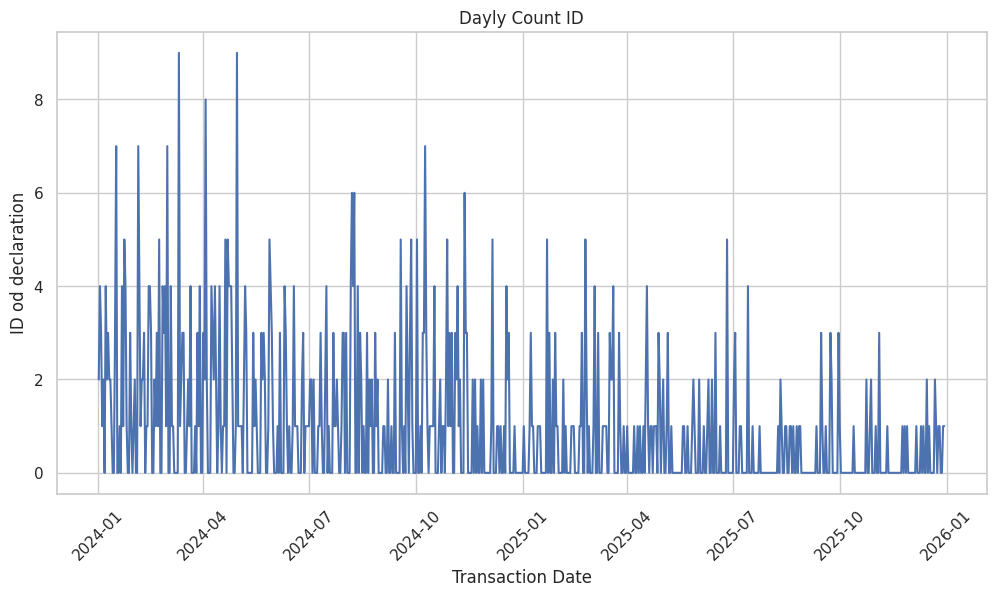

In [125]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=daily_count_id ,
    x='Date',
    y='ID of declaration'
)

plt.title('Dayly Count ID')
plt.xlabel('Transaction Date')
plt.ylabel('ID od declaration')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [126]:
quarter_count_id = df_clean.resample('Q')['ID of declaration'].count().reset_index()
quarter_count_id

/tmp/ipykernel_3766/3772103842.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarter_count_id = df_clean.resample('Q')['ID of declaration'].count().reset_index()


,Date,ID of declaration
0,2024-03-31,163
1,2024-06-30,145
2,2024-09-30,112
3,2024-12-31,104
4,2025-03-31,72
5,2025-06-30,54
6,2025-09-30,39
7,2025-12-31,28


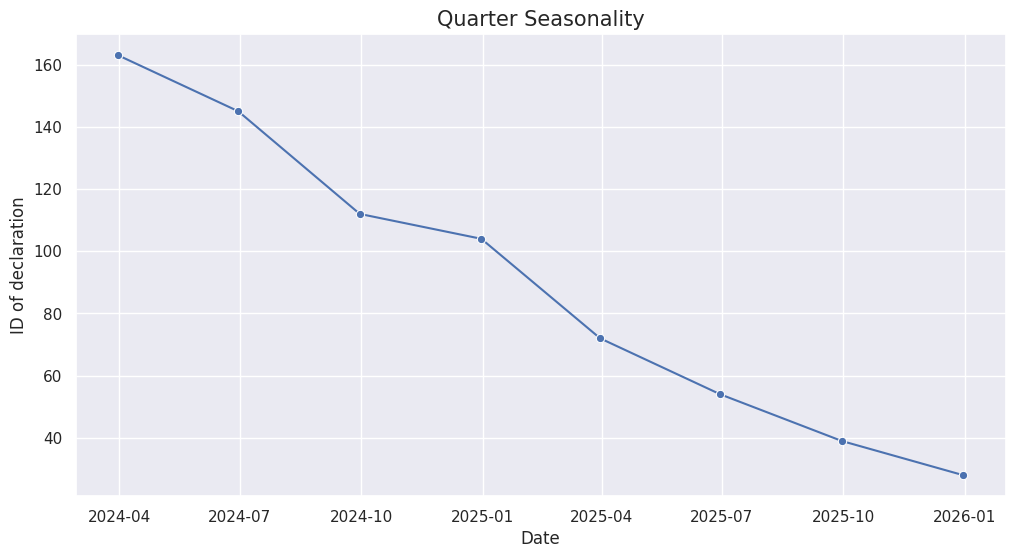

In [127]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=quarter_count_id,
    x='Date',
    y='ID of declaration',
    marker='o'
)
plt.title('Quarter Seasonality', fontsize=15)
plt.xlabel('Date')
plt.ylabel('ID of declaration')
plt.show()

In [128]:
df_clean = df_clean.reset_index()


In [129]:
df_clean['WeekDay'] = df_clean['Date'].dt.weekday
df_clean

,Date,Type of declaration,Client,Good,Broker,ID of declaration,Year,Month number,Month name,Week Number,Quarter,WeekDay
0,2024-01-02,ЕК,ДСР,судно,Іра,000021U1,2024.0,1.0,Січень,1.0,1.0,1.0
1,2024-01-02,ЕК,Долинський Елеватор,пшениця,Ліана,017517U3,2024.0,1.0,Січень,1.0,1.0,1.0
2,2024-01-03,ЕК,Золотой Дракон,шрот,Надя,000048U4,2024.0,1.0,Січень,1.0,1.0,2.0
3,2024-01-03,ЕК,Белогви,кукурудза,Надя,000054U2,2024.0,1.0,Січень,1.0,1.0,2.0
4,2024-01-03,ЕК,Китайпром,пшениця,Надя,017579U9,2024.0,1.0,Січень,1.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
715,2025-12-25,IM,Дунайсудоремонт,брухт,Надя,25UA500530004153U7,2025.0,12.0,Грудень,51.0,4.0,3.0
716,2025-12-26,ЕК,"ПП ""ГІДРОСЕНД""",шрот,Надя,25UA500530004160U4,2025.0,12.0,Грудень,51.0,4.0,4.0
717,2025-12-29,ЕК,Промбудресурс КР,шлак,Надя,25UA500530004188U6,2025.0,12.0,Грудень,52.0,4.0,0.0
718,2025-12-30,ЕК,Промбудресурс КР,щебінь,Надя,25UA500530004202U2,2025.0,12.0,Грудень,52.0,4.0,1.0


In [130]:
daily_counts = df_clean.groupby(['Date', 'WeekDay'])['ID of declaration'].count().reset_index()
weekday_mean_id = daily_counts.groupby('WeekDay')["ID of declaration"].mean().reset_index()
weekday_mean_id

,WeekDay,ID of declaration
0,0.0,2.490909
1,1.0,2.183099
2,2.0,2.491803
3,3.0,2.000000
4,4.0,1.983051
5,5.0,1.409091
6,6.0,1.250000


In [131]:
days_map = {
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday',
    3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'
}

In [132]:
weekday_mean_id['WeekDay'] = weekday_mean_id['WeekDay'].map(days_map)
weekday_mean_id

,WeekDay,ID of declaration
0,Monday,2.490909
1,Tuesday,2.183099
2,Wednesday,2.491803
3,Thursday,2.000000
4,Friday,1.983051
5,Saturday,1.409091
6,Sunday,1.250000


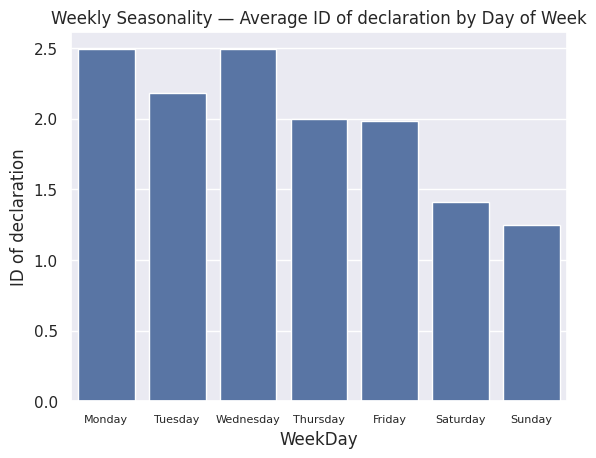

In [133]:
sns.barplot(
    data=weekday_mean_id,
    x="WeekDay",
    y="ID of declaration",
    errorbar=None
)

plt.title("Weekly Seasonality — Average ID of declaration by Day of Week")
plt.xlabel("WeekDay")
plt.ylabel("ID of declaration")
plt.xticks(fontsize=8)
plt.show()

In [134]:
weekday_year_count_id = df_clean.groupby(['WeekDay', 'Year'])['ID of declaration'].count().reset_index()
weekday_year_count_id

,WeekDay,Year,ID of declaration
0,0.0,2024.0,94
1,0.0,2025.0,43
2,1.0,2024.0,111
3,1.0,2025.0,44
4,2.0,2024.0,120
5,2.0,2025.0,32
6,3.0,2024.0,90
7,3.0,2025.0,30
8,4.0,2024.0,81
9,4.0,2025.0,36


In [93]:
weekday_year_count_id['WeekDay'] = weekday_year_count_id['WeekDay'].map(days_map)
weekday_year_count_id

,WeekDay,Year,ID of declaration
0,Monday,2024.0,94
1,Monday,2025.0,43
2,Tuesday,2024.0,111
3,Tuesday,2025.0,44
4,Wednesday,2024.0,120
5,Wednesday,2025.0,32
6,Thursday,2024.0,90
7,Thursday,2025.0,30
8,Friday,2024.0,81
9,Friday,2025.0,36


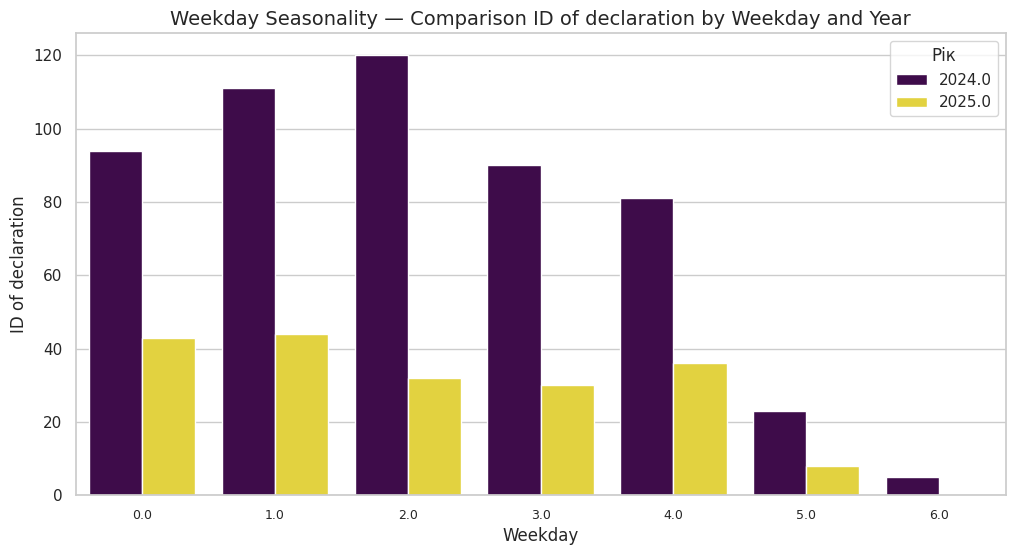

In [135]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=weekday_year_count_id,
    x="WeekDay",
    y="ID of declaration",
    hue="Year",
    palette="viridis"
)

plt.title("Weekday Seasonality — Comparison ID of declaration by Weekday and Year", fontsize=14)
plt.xlabel("Weekday", fontsize=12)
plt.ylabel("ID of declaration", fontsize=12)
plt.legend(title='Рік')
plt.xticks(fontsize=9)
plt.show()

In [136]:
monthly_count_id = df_clean.groupby(['Year','Month name'])["ID of declaration"].count().sort_values(ascending=False).reset_index()
monthly_mean_id = monthly_count_id.groupby('Month name')["ID of declaration"].mean().sort_values(ascending=False).reset_index()
monthly_mean_id

,Month name,ID of declaration
0,Квітень,47.0
1,Січень,40.5
2,Лютий,39.0
3,Березень,38.0
4,Травень,29.5
5,Серпень,29.5
6,Жовтень,27.5
7,Липень,24.0
8,Червень,23.0
9,Вересень,22.0


# CONCLUSION ON SEASONALITY

Спираючись на представлені графіки та таблиці, можна зробити комплексний аналіз сезонності кількості декларацій у відділі.

Ось основні висновки, розподілені за рівнями аналітики:

1. Глобальний тренд та квартальна сезонність (Quarter Seasonality)
Падіння обсягів: На графіку Quarter Seasonality чітко видно сильний спадний тренд. Починаючи з другого кварталу 2024 року (2024-04), кількість декларацій стабільно та стрімко зменшується — зі 160+ до менш ніж 40 на початок 2026 року.

Висновок: Відбувається загальне скорочення навантаження або обсягів роботи відділу в часі. Через це класичну річну сезонність виявити складно — лінійний тренд «задавлює» сезонні коливання.

2. Щомісячна активність (Monthly)
Якщо проаналізувати зведену таблицю monthly_count_id (агреговану за весь період):

Пікові місяці: Найбільша активність припадає на квітень (47 декларацій), а також на зимово-весняний період — січень (40,5), лютий (39) та березень (38).

Спад: Найнижчий показник зафіксовано у грудні (16,5). Літо та осінь тримаються на середньому рівні (22–30 декларацій).

3. Тижнева сезонність (Weekly / Weekday Seasonality)
Тут спостерігається найчіткіша та найстабільніша сезонність:

Робочі дні (Пік): Основний обсяг роботи виконується у понеділок та середу. Вівторок, четвер та п'ятниця теж завантажені, але трохи менше.

Вихідні (Спад): У суботу активність різко падає, а в неділю практично повністю відсутня (поодинокі декларації).

4. Порівняння тижневої активності за роками (2024 vs 2025)
Підтвердження тренду: Графік порівняння років наочно ілюструє падіння обсягів: у 2025 році (жовті стовпчики) кількість декларацій в усі дні тижня впала більш ніж удвічі порівняно з 2024 роком (фіолетові стовпчики).

Зміщення пікових днів: Цікаво, що у 2024 році найзавантаженішим днем була середа, а у 2025 році пік змістився на понеділок та вівторок. Проте загальна логіка «працюємо в будні, відпочиваємо у вихідні» залишилася незмінною.

# EXECUTIVE SUMMARY

Головним фактором, що визначає вигляд графіків, є не сезонність, а сильний спадний тренд — загальна кількість оформлених декларацій у відділі скоротилася в кілька разів за аналізований період (2024–2025 рр.). У 2025 році оформлено 190 декларації проти 521 у 2024-му — падіння на 65%. Середньомісячний показник впав з 43 до 16 декларацій. Західдорбуд (196 декл.), Промбудресурс КР (105 декл.) та Дунайсудноремонт (124 декл.) разом дають ~60% усіх декларацій. Втрата хоча б одного критично вдарить по відділу. В 2025 відділ втратив клієнта Західдорбуд. Відділ спеціалізується на експортних операціях — переважно зернові (455 експортних декларацій в 2024, 151 експортних декл. в 2025)

# RECOMMENDATIONS

1. Диверсифікувати клієнтську базу
Жоден клієнт не повинен давати >15% обсягу. Зараз Західдорбуд — 27,5%. Активно залучати нових клієнтів.
2. Планувати відпустки в низький сезон
Червень–липень, грудень — традиційний спад. Брати відпустки тоді, а не в квітні, коли пік навантаження
3. Експортні декларації складають 85% оформлень. Рекомендовано розширити процеси декларування, впроваджуючи комплексне оформлення всіх митних режимів (імпорт, експорт, транзит).
4. Ввести місячний KPI для брокерів. Щомісяця звіряти факт з планом, не чекати кінця року.
5. Найняти нового брокера замість Іри
 Без нового співробітника ріст неможливий.



